## Lab 1: Key Connection

### Introduction to the problem

The transport system carries coal carts from a boat to the factory. The mechanical system uses an asynchronous motor connected to a drive pulley via a keyed shaft connection. A thin-profile V-belt transfers power to the input of a single-stage gearbox, which connects through an output shaft coupling to drive the sprocket and chain mechanism.

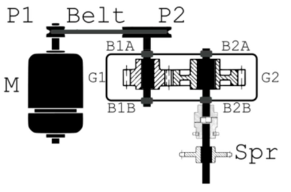

**Assignment**


In this assignment, we select the motor for the system and determine the required transmission ratios. We also estimate and evaluate the application factor ($K_A$) and efficiency ($\eta$). The motor choice relies on output power, motor speed, sprocket diameter, linear velocity, and overall transmission ratios.

## Initializing

In [4]:
# Motor Selection - Class 1

# Import statements
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import math

import MechDesign.Helpers as HM

from MechDesign.Units.Units import m_, mm_, kg_, s_, N_, rpm_, W_, h_
import MechDesign.Units.UnitMethods as UM

import MechDesign.RnM as RnM

## Classes

In [14]:
# Define classes for the calculation of ratio and motor power

class RatioCalculation:
    """ Calculate Ratio from output speed """
    def __init__(self):
        """ Symbols defenition """ 
        self.omega_in = HM.MySymbol('omega_in', 'input rotational speed (rad/s)')
        self.v = HM.MySymbol('v', 'linear speed on output')
        self.d = HM.MySymbol('d', 'sprocket diameter')
        self.i = HM.MySymbol('i', 'ratio i_b/i_g')
        

class MotorPower:
    """ Motor Power data """
    def __init__(self):
        self.P = HM.MySymbol('P', 'power given at output')
        self.eta = HM.MySymbol('eta', 'efficiency')
        self.K_A = HM.MySymbol('K_A', 'application facotr')


## Objects

In [13]:
# Create instances of the classes
RC = RatioCalculation()  
MP = MotorPower()

## Formulas

Output Angular speed ($\omega_{out}$): 

$$\omega_{out} = \frac{v}{d/2}$$

Total Transmission Ratio 

$$i_{total} = \frac{\omega_{in}}{\omega_{out}}$$


Stage Reduction Ratios ($i_g, i_b$):Given that $i_{total} = i_b \cdot i_g$ and the design constraint parameter $i = \frac{i_b}{i_g}$, substituting $i_b = i \cdot i_g$ yields:


$$
i_{total} = (i \cdot i_g) \cdot i_g
= i \cdot i_g^2
\implies
i_g = \sqrt{\frac{i_{total}}{i}}
$$

$$
i_b = i \cdot i_g
$$

Motor Power ($P_{Motor}$): Adjusts output power for service severe duty ($K_A$) and mechanical efficiency losses ($\eta$): 
$$P_{Motor} = \frac{P \cdot K_A}{\eta}$$

In [11]:

# Kinematic Formulas for Gear Ratio Calculation
RC.omega_out = RC.v/(RC.d/2)
RC.i_total = RC.omega_in/RC.omega_out
RC.i_g = (RC.i_total/RC.i)**0.5
RC.i_b = RC.i*RC.i_g

# Formula for power calculation
MP.P_Motor = MP.P*MP.K_A/MP.eta


## Values



- velocity:
  $v = 15.5\text{ km/h} = 15.5 \times 10^3\text{ m/h}$

- Sprocket pitch diameter:
  $d = 550\text{ mm}$

- Asynchronous motor rated speed:
  $\omega_{in} = 1500\text{ rpm}$

-  Ratio of reduction:
  $i = \frac{3}{5} = 0.6$

- Required mechanical output power:
  $P = 8\text{ kW} = 8 \times 10^3\text{ W}$

- combined efficiency estimate:
  $\eta = 0.90\text{ (90\%)}$

- Application factor:
  $K_A = 1.35$
  (accounting for moderate operational shocks)

In [8]:

# Assign numerical values
RC.v = 15.5*pow(10,3)*m_/h_
RC.d = 550*mm_
RC.omega_in = 1500*rpm_
RC.i = 3/5

MP.P = 8*pow(10,3)*W_
MP.eta = 0.9
MP.K_A = 1.35

## Substitution

In [9]:
# Evaluate and print Output Angular Velocity (omega_out)
RC.omega_out = HM.substitute(RC.omega_out, RC)
RC.omega_out = UM.All_to_SI(RC.omega_out)
HM.EqPrint('omega_out', RC.omega_out)

# Evaluate and print Total Speed Reduction Ratio (i_total)
RC.i_total = HM.substitute(RC.i_total, RC)
RC.i_total = UM.All_to_SI(RC.i_total)
HM.EqPrint('i_total', RC.i_total)

# Evaluate and print Gearbox Stage Ratio (i_g)
RC.i_g = HM.substitute(RC.i_g, RC)
RC.i_g = UM.All_to_SI(RC.i_g)
HM.EqPrint('i_g', RC.i_g)

# Evaluate and print Belt Drive Stage Ratio (i_b)
RC.i_b = HM.substitute(RC.i_b, RC)
RC.i_b = UM.All_to_SI(RC.i_b)
HM.EqPrint('i_b', RC.i_b)

# Evaluate and print Required Electric Motor Power (P_Motor)
MP.P_Motor = HM.substitute(MP.P_Motor, MP)
HM.EqPrint('P_Motor', MP.P_Motor)
t=0


Eq(omega_out, 15.66/s_)

Eq(i_total, 10.03)

Eq(i_g, 4.089)

Eq(i_b, 2.454)

Eq(P_Motor, 12000.0*W_)

## Plot

For our base design for the motor selection ($\eta = 0.90$, $K_A = 1.35$), the computed power requirement is

$$
P_{Motor} = 12.0\text{ kW}.
$$

The plot demonstrates that an $11\text{ kW}$ motor would operate in a continuously overloaded state under nominal conditions.

Consequently, a standard $15\text{ kW}$ frame size is selected, providing a necessary power margin to accommodate potential mechanical wear, efficiency degradation, or transient shock loads during operation.

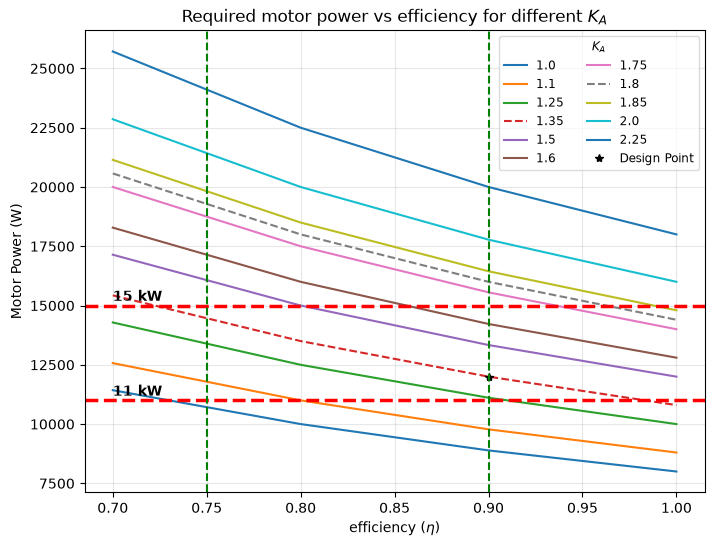

In [12]:
# Create symbolic variables for K_A and eta
KA = HM.MySymbol('K_A', 'application factor')
Eta = HM.MySymbol('eta', 'efficiency')

# Define the symbolic expression for motor power as a function of K_A and eta
MP.P_Motor_KA = MP.P*KA/Eta

# Range of values for K_A and eta
KA_vals = [1.00, 1.10, 1.25, 1.35, 1.50, 1.60, 1.75, 1.80, 1.85, 2.00, 2.25]
Eta_vals = np.arange(0.7,1,0.1)

# Evaluate the motor power for each combination of K_A and eta
P_vals, A, B = HM.evaluate(MP.P_Motor_KA, {'eta': Eta_vals, 'K_A': KA_vals})

# Plot the results
fig, ax = plt.subplots(figsize=(8, 6))
lines = ax.plot(Eta_vals, P_vals)
lines[KA_vals.index(1.35)].set_linestyle('--')
lines[KA_vals.index(1.8)].set_linestyle('--')
point = ax.plot(0.9, 12000, 'k*')
ax.legend(lines + point, KA_vals + ['Design Point'], title='$K_A$',
        loc='upper right', ncol=2, fontsize='small', title_fontsize='small',
        framealpha=0.7)
ax.set_title('Required motor power vs efficiency for different $K_A$')
ax.set_xlabel(r'efficiency ($\eta$)')
ax.set_ylabel('Motor Power (W)')


ax.axhline(11000, color='red', linestyle='--', linewidth=2.5)
ax.axhline(15000, color='red', linestyle='--', linewidth=2.5)
ax.text(0.70, 11200, '11 kW', fontweight='bold')
ax.text(0.70, 15200, '15 kW', fontweight='bold')
ax.axvline(0.75, color='green', linestyle='--')
ax.axvline(0.9, color='green', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()
